## Data Overview

In [3]:
import os
import re
import pandas as pd

# Replace this with your actual data directory
data_dir = "/home/awibisono1/ecgxai/data/emglab/raw_wav"
filenames = [f for f in os.listdir(data_dir) if f.startswith("N2001")]

def parse_filename(fname):
    """
    Parses EMGLab N2001 filenames like 'N2001A01BB02.wav'
    Returns subject ID, label, muscle, and recording ID
    """
    # Allow optional ".wav" at the end
    pattern = r"N2001([AMC])(\d+)([A-Z]{2})(\d+)(?:\.wav)?$"
    match = re.match(pattern, fname)
    if not match:
        return None

    label_code = match.group(1)
    subject_id = match.group(2)
    muscle = match.group(3)
    rec_id = int(match.group(4))

    label_map = {"A": "ALS", "M": "Myopathy", "C": "Normal"}

    return {
        "filename": fname,
        "subject": f"{label_code}{subject_id}",
        "label": label_map[label_code],
        "muscle": muscle,
        "rec_id": rec_id,
    }

# Parse all filenames
records = [parse_filename(f) for f in filenames]
records = [r for r in records if r is not None]
df = pd.DataFrame(records)

# Preview the metadata table
print(df)

# ---- Added: subject count + subject names ----
subjects = sorted(df["subject"].unique())
print("\nNumber of subjects (unique people):", len(subjects))
print("Subjects:")
print(subjects)


ModuleNotFoundError: No module named 'pandas'

In [ ]:
from scipy.io import wavfile
import os

# pick one file from your dataframe
example_file = df.iloc[0]["filename"]

file_path = os.path.join(data_dir, example_file)

fs, signal = wavfile.read(file_path)

print("File:", example_file)
print("Sampling rate:", fs)
print("Signal shape:", signal.shape)
print("Data type:", signal.dtype)

import numpy as np

print("Min:", np.min(signal))
print("Max:", np.max(signal))
print("Mean:", np.mean(signal))
print("Std:", np.std(signal))

File: N2001A01AP51.wav
Sampling rate: 23438
Signal shape: (262144,)
Data type: int16
Min: -31232
Max: 27278
Mean: -4.085170745849609
Std: 1222.4495759505594


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import GroupKFold

K = 5
ALLOWED_PREFIXES = ("A", "M", "C")
TEST_FRAC        = 0.10   # ~10% of subjects per prefix held out as test
TEST_RANDOM_STATE = 0     # seed for test split
CV_RANDOM_STATE   = 42    # seed for CV fold assignment

dfw = df.copy()
dfw["subject"] = dfw["subject"].astype(str)
dfw["prefix"]  = dfw["subject"].str[0]
dfw = dfw[dfw["prefix"].isin(ALLOWED_PREFIXES)].copy()

# Counts per subject
counts = dfw.groupby("subject")["filename"].count().sort_index()

# Original plot (filtered)
plt.figure(figsize=(12, 4))
plt.bar(counts.index, counts.values)
plt.xticks(rotation=90)
plt.xlabel("Subject (A/M/C only)")
plt.ylabel("Number of recordings")
plt.title("Recordings per subject (filtered)")
plt.tight_layout()
plt.show()


def greedy_balance_subjects(subject_counts: pd.Series, k: int, random_state: int = 0):
    rng = np.random.default_rng(random_state)
    sc = subject_counts.sort_values(ascending=False)
    tmp = sc.reset_index()
    tmp.columns = ["subject", "n"]
    tmp["tie_rand"] = rng.random(len(tmp))
    tmp = tmp.sort_values(["n", "tie_rand"], ascending=[False, True])

    totals = np.zeros(k, dtype=int)
    subj2bin = {}
    for subj, n in zip(tmp["subject"], tmp["n"]):
        b = int(np.argmin(totals))
        subj2bin[subj] = b
        totals[b] += int(n)

    bin_totals = pd.Series(totals, index=list(range(k)), name="total_recordings")
    return subj2bin, bin_totals


# ============================================================
# NEW: Random stratified test split — ~10% of subjects per prefix
# ============================================================
rng_test     = np.random.default_rng(TEST_RANDOM_STATE)
test_subjects = set()

for p in ALLOWED_PREFIXES:
    subjects_p = counts[counts.index.str.startswith(p)].index.tolist()
    if len(subjects_p) == 0:
        continue
    n_test = max(1, round(TEST_FRAC * len(subjects_p)))   # at least 1
    chosen = rng_test.choice(subjects_p, size=n_test, replace=False).tolist()
    test_subjects.update(chosen)

# Mark rows
dfw["is_test"] = dfw["subject"].isin(test_subjects)

df_test = dfw[dfw["is_test"]].copy()
df_cv   = dfw[~dfw["is_test"]].copy()

print(f"\n=== Test split ===")
print(f"  Test  subjects : {sorted(test_subjects)}")
print(f"  Test  rows     : {len(df_test)}  ({100*len(df_test)/len(dfw):.1f}%)")
print(f"  CV    rows     : {len(df_cv)}  ({100*len(df_cv)/len(dfw):.1f}%)")

# ----------------------------
# Visualise test set
# ----------------------------

# Test recordings per prefix
test_prefix_counts = df_test.groupby("prefix")["filename"].count().reindex(list(ALLOWED_PREFIXES), fill_value=0)
cv_prefix_counts   = df_cv.groupby("prefix")["filename"].count().reindex(list(ALLOWED_PREFIXES), fill_value=0)

plt.figure(figsize=(8, 4))
x = np.arange(len(ALLOWED_PREFIXES))
width = 0.35
plt.bar(x - width/2, cv_prefix_counts.values,   width=width, label="CV",   color="steelblue")
plt.bar(x + width/2, test_prefix_counts.values, width=width, label="Test", color="salmon")
plt.xticks(x, list(ALLOWED_PREFIXES))
plt.xlabel("Prefix")
plt.ylabel("Number of recordings")
plt.title("CV vs Test recordings per prefix")
plt.legend()
plt.tight_layout()
plt.show()

# Test recordings per subject (who actually ended up in test)
test_subject_counts = df_test.groupby("subject")["filename"].count().sort_index()

plt.figure(figsize=(12, 4))
plt.bar(test_subject_counts.index, test_subject_counts.values, color="salmon")
plt.xticks(rotation=90)
plt.xlabel("Subject")
plt.ylabel("Number of recordings")
plt.title(f"Test set: recordings per subject ({len(test_subject_counts)} subjects, {len(df_test)} recordings total)")
plt.tight_layout()
plt.show()

# Overall train/val/test proportions as a stacked bar
total        = len(dfw)
test_size    = len(df_test)
cv_size      = len(df_cv)
example_val  = fold_totals.mean()   # average val size across folds
example_train = cv_size - example_val

plt.figure(figsize=(6, 4))
plt.bar(["Split"], [example_train], label=f"Train (~avg per fold)")
plt.bar(["Split"], [example_val],   label=f"Val (~avg per fold)",   bottom=[example_train])
plt.bar(["Split"], [test_size],     label=f"Test (held out)",       bottom=[example_train + example_val])
plt.ylabel("Number of recordings")
plt.title("Average train / val / test split sizes")
plt.legend(loc="upper right")
plt.tight_layout()
plt.show()
# Recompute counts on CV subjects only
counts_cv = df_cv.groupby("subject")["filename"].count().sort_index()

# ============================================================
# Build CV fold mappings (unchanged logic, but on CV set only)
# ============================================================
subject_to_bin_key = {}
bin_key_to_label   = {}
bin_key_to_fold_id = {}
per_prefix_groups  = {}

for p in ALLOWED_PREFIXES:
    c_p = counts_cv[counts_cv.index.str.startswith(p)]
    if len(c_p) == 0:
        continue

    subj2bin, _ = greedy_balance_subjects(c_p, k=K, random_state=CV_RANDOM_STATE)
    per_prefix_groups[p] = {b: [] for b in range(K)}

    for subj, b in subj2bin.items():
        bin_key = f"{p}_bin{b}"
        subject_to_bin_key[subj] = bin_key
        bin_key_to_fold_id[bin_key] = b
        per_prefix_groups[p][b].append(subj)

    for b in range(K):
        members_sorted = sorted(per_prefix_groups[p][b])
        bin_key = f"{p}_bin{b}"
        bin_key_to_label[bin_key] = repr(members_sorted)

# Apply mappings to CV rows only
df_cv = df_cv.copy()
df_cv["bin_key"] = df_cv["subject"].map(subject_to_bin_key)
if df_cv["bin_key"].isna().any():
    bad = df_cv.loc[df_cv["bin_key"].isna(), "subject"].unique().tolist()
    raise ValueError(f"Unmapped subjects found: {bad}")

df_cv["fold_id"]      = df_cv["bin_key"].map(bin_key_to_fold_id).astype(int)
df_cv["merged_group"] = df_cv["bin_key"].map(bin_key_to_label)

# ----------------------------
# Visualise — same plots as before, now on CV set
# ----------------------------
merged_counts = df_cv.groupby("merged_group")["filename"].count().sort_values(ascending=False)
plt.figure(figsize=(12, 4))
plt.bar(merged_counts.index.astype(str), merged_counts.values)
plt.xticks(rotation=90)
plt.xlabel("Merged group (patients in bin)")
plt.ylabel("Number of recordings")
plt.title(f"Totals after merging patients into CV bins, K={K} (test held out)")
plt.tight_layout()
plt.show()

fold_totals = df_cv.groupby("fold_id")["filename"].count().reindex(range(K), fill_value=0)
plt.figure(figsize=(10, 4))
plt.bar(fold_totals.index.astype(str), fold_totals.values)
plt.axhline(fold_totals.mean(), linestyle="--")
plt.xlabel("Fold / bin id")
plt.ylabel("Validation recordings (if held out)")
plt.title("CV validation size per fold (should be similar)")
plt.tight_layout()
plt.show()

prefix_fold = (
    df_cv.groupby(["prefix", "fold_id"])["filename"].count()
         .unstack(fill_value=0)
         .reindex(index=list(ALLOWED_PREFIXES), fill_value=0)
         .reindex(columns=range(K), fill_value=0)
)

plt.figure(figsize=(12, 4))
x = np.arange(K)
width = 0.25
for i, p in enumerate(ALLOWED_PREFIXES):
    if p in prefix_fold.index:
        plt.bar(x + (i-1)*width, prefix_fold.loc[p].values, width=width, label=p)
plt.xticks(x, [str(i) for i in range(K)])
plt.xlabel("Fold / bin id")
plt.ylabel("Recordings")
plt.title("CV validation recordings per fold (A vs M vs C)")
plt.tight_layout()
plt.legend()
plt.show()

prefix_total_cv = (
    df_cv.groupby("prefix")["filename"].count()
         .reindex(list(ALLOWED_PREFIXES), fill_value=0)
)
train_prefix_fold = prefix_fold.copy()
for p in train_prefix_fold.index:
    train_prefix_fold.loc[p] = prefix_total_cv.loc[p] - prefix_fold.loc[p]

plt.figure(figsize=(12, 4))
for i, p in enumerate(ALLOWED_PREFIXES):
    if p in train_prefix_fold.index:
        plt.bar(x + (i-1)*width, train_prefix_fold.loc[p].values, width=width, label=p)
plt.xticks(x, [str(i) for i in range(K)])
plt.xlabel("Fold / bin id (held-out fold)")
plt.ylabel("TRAIN recordings")
plt.title("Train recordings per fold (A vs M vs C)")
plt.tight_layout()
plt.legend()
plt.show()

train_totals = df_cv.shape[0] - fold_totals
plt.figure(figsize=(10, 4))
plt.bar(train_totals.index.astype(str), train_totals.values)
plt.axhline(train_totals.mean(), linestyle="--")
plt.xlabel("Fold / bin id (held-out fold)")
plt.ylabel("TRAIN recordings")
plt.title("Total train recordings per fold (test held out)")
plt.tight_layout()
plt.show()

# ----------------------------
# Print bin composition clearly
# ----------------------------
print("\n=== Test subjects per prefix ===")
for p in ALLOWED_PREFIXES:
    ts    = sorted(s for s in test_subjects if s.startswith(p))
    total = int(counts.reindex(ts).fillna(0).sum())
    print(f"  {p}: {ts} -> {total} recordings")

print("\n=== CV bin labels ===")
for p in ALLOWED_PREFIXES:
    if p not in per_prefix_groups:
        continue
    print(f"\nPrefix {p}:")
    for b in range(K):
        members = sorted(per_prefix_groups[p][b])
        total   = int(counts_cv.reindex(members).fillna(0).sum())
        print(f"  fold {b}: {repr(members)} -> {total} recordings")

# ----------------------------
# K-fold split on CV set
# ----------------------------
gkf        = GroupKFold(n_splits=K)
X_cv       = df_cv.index.to_numpy()
groups_arr = df_cv["fold_id"].to_numpy()

fold_summary = []
for fold, (train_idx, val_idx) in enumerate(gkf.split(X_cv, groups=groups_arr), start=0):
    fold_summary.append({
        "fold":            fold,
        "train_samples":   len(train_idx),
        "val_samples":     len(val_idx),
        "val_bins_labels": sorted(df_cv.iloc[val_idx]["merged_group"].unique().tolist())
    })

fold_summary_df = pd.DataFrame(fold_summary)
print("\n=== Fold summary (CV only, test excluded) ===")
print(fold_summary_df[["fold", "train_samples", "val_samples"]])
for _, r in fold_summary_df.iterrows():
    print(f"fold {int(r['fold'])} holds out bins: {r['val_bins_labels']}")

print(f"\n=== Final test set: {len(df_test)} rows ({100*len(df_test)/len(dfw):.1f}% of total) ===")

ModuleNotFoundError: No module named 'numpy'

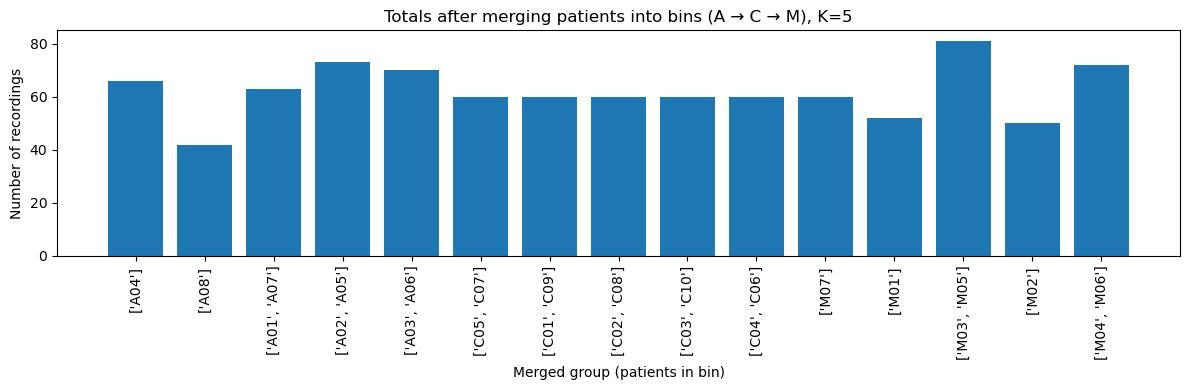

In [ ]:
# ----------------------------
# Visualise totals per merged group label
# Sorted as: A bins -> C bins -> M bins
# ----------------------------

# 1) total recordings per *bin_key* (keeps prefix + bin info)
bin_totals = dfw.groupby("bin_key")["filename"].count()

# 2) map each bin_key to its display label (list of patients)
bin_totals_labeled = bin_totals.rename(index=bin_key_to_label)

# 3) custom order: A first, then C, then M; within each prefix sort by bin id (0..K-1)
prefix_order = {"A": 0, "C": 1, "M": 2}

# Build a sort key from the original bin_key (not the label)
order_df = (
    bin_totals.reset_index()  # columns: bin_key, count
)
order_df["prefix"] = order_df["bin_key"].str[0]
order_df["bin_id"] = order_df["bin_key"].str.extract(r"_bin(\d+)$").astype(int)
order_df["prefix_rank"] = order_df["prefix"].map(prefix_order)

# sort by prefix order, then bin id
order_df = order_df.sort_values(["prefix_rank", "bin_id"])

# get the ordered labels
ordered_labels = order_df["bin_key"].map(bin_key_to_label).tolist()

# reindex the labeled totals to that order
merged_counts_sorted = bin_totals_labeled.reindex(ordered_labels)

plt.figure(figsize=(12, 4))
plt.bar(merged_counts_sorted.index.astype(str), merged_counts_sorted.values)
plt.xticks(rotation=90)
plt.xlabel("Merged group (patients in bin)")
plt.ylabel("Number of recordings")
plt.title(f"Totals after merging patients into bins (A → C → M), K={K}")
plt.tight_layout()
plt.show()

Recordings per class:
label
Myopathy    315
ALS         314
Normal      300
Name: count, dtype: int64

Recordings per muscle:
muscle
BB    501
VM    241
DE     84
TA     53
TF     21
AP     14
VL     12
TB      3
Name: count, dtype: int64

Cross-tabulation (Class × Muscle):
muscle    AP   BB  DE  TA  TB  TF  VL   VM
label                                     
ALS       14   94  26  37   0   0  12  131
Myopathy   0  107  58  16   3  21   0  110
Normal     0  300   0   0   0   0   0    0


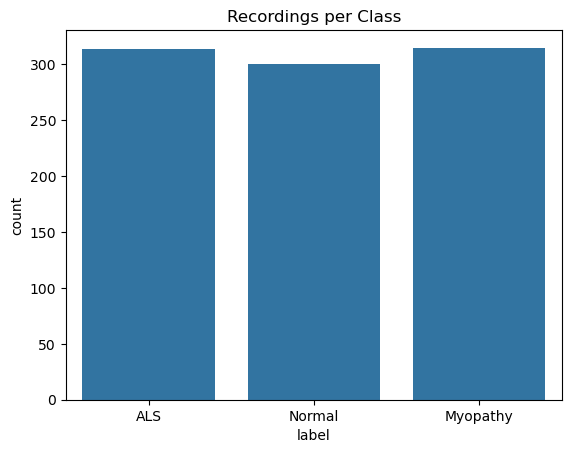

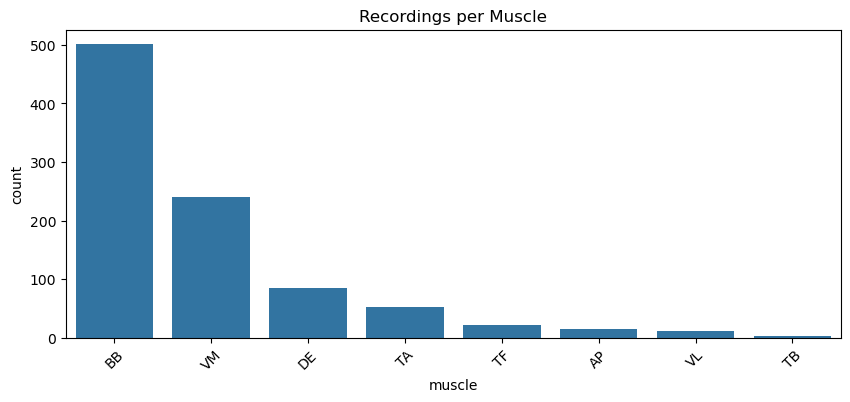

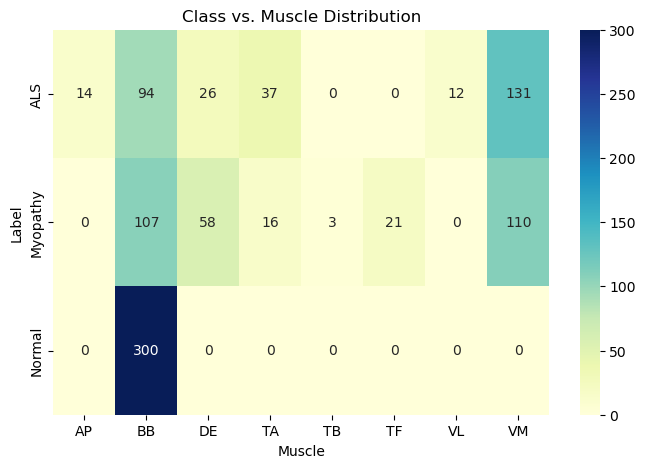

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming you already have your metadata dataframe from Step 1:
# columns: ['filename', 'subject', 'label', 'muscle', 'rec_id']

# Basic class counts
print("Recordings per class:")
print(df['label'].value_counts())

# Recordings per muscle
print("\nRecordings per muscle:")
print(df['muscle'].value_counts())

# Class x Muscle matrix
print("\nCross-tabulation (Class × Muscle):")
class_muscle_table = pd.crosstab(df['label'], df['muscle'])
print(class_muscle_table)

# Plot: class distribution
sns.countplot(data=df, x='label')
plt.title("Recordings per Class")
plt.show()

# Plot: muscle distribution
plt.figure(figsize=(10, 4))
sns.countplot(data=df, x='muscle', order=df['muscle'].value_counts().index)
plt.title("Recordings per Muscle")
plt.xticks(rotation=45)
plt.show()

# Plot: heatmap of class vs muscle
plt.figure(figsize=(8, 5))
sns.heatmap(class_muscle_table, annot=True, fmt="d", cmap="YlGnBu")
plt.title("Class vs. Muscle Distribution")
plt.ylabel("Label")
plt.xlabel("Muscle")
plt.show()


## Signal Analysis and Visualisation

C:\Users\Wibisono\AppData\Local\Temp\ipykernel_28576\3733949450.py:28: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(samples_per_class, random_state=42))


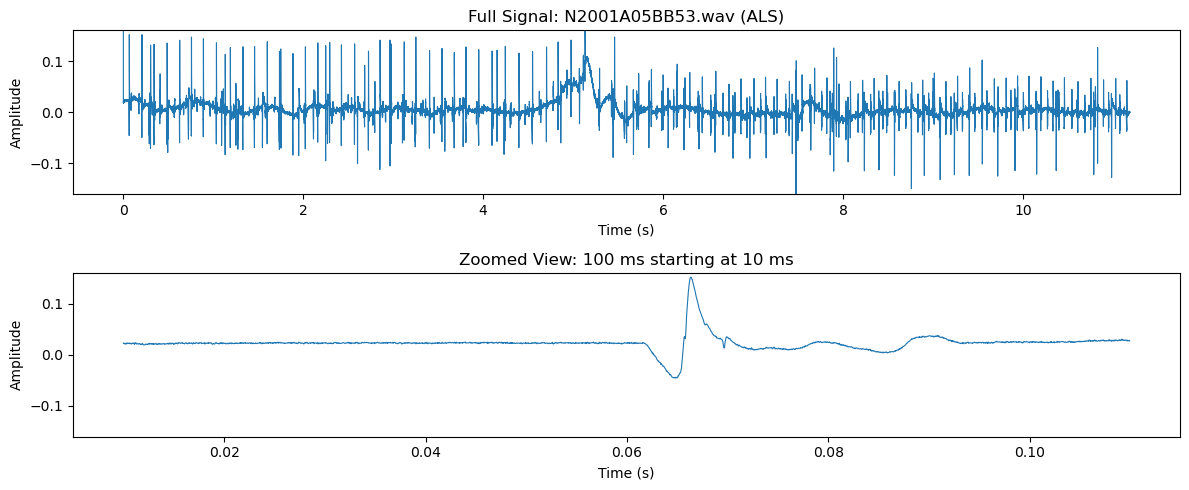

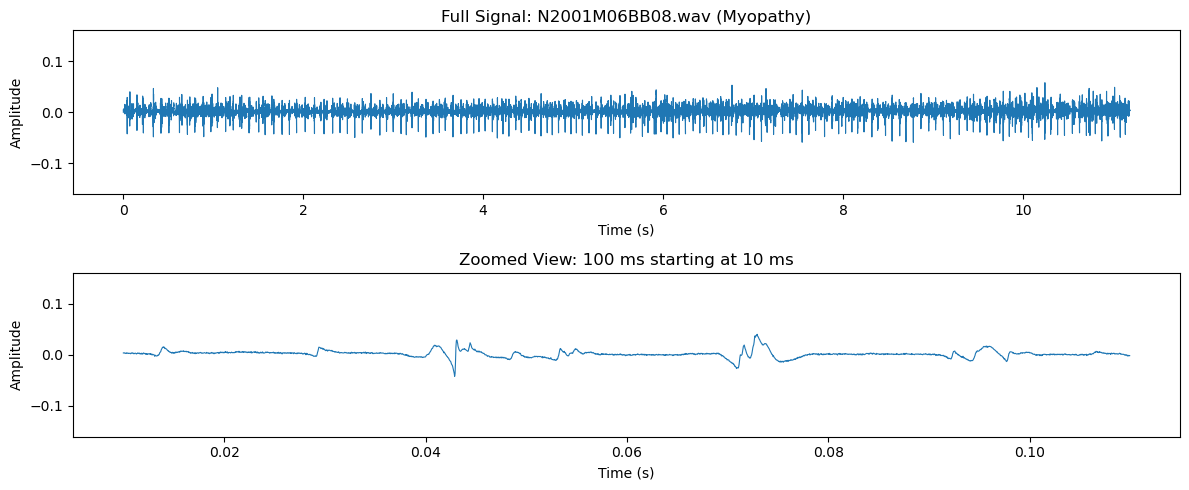

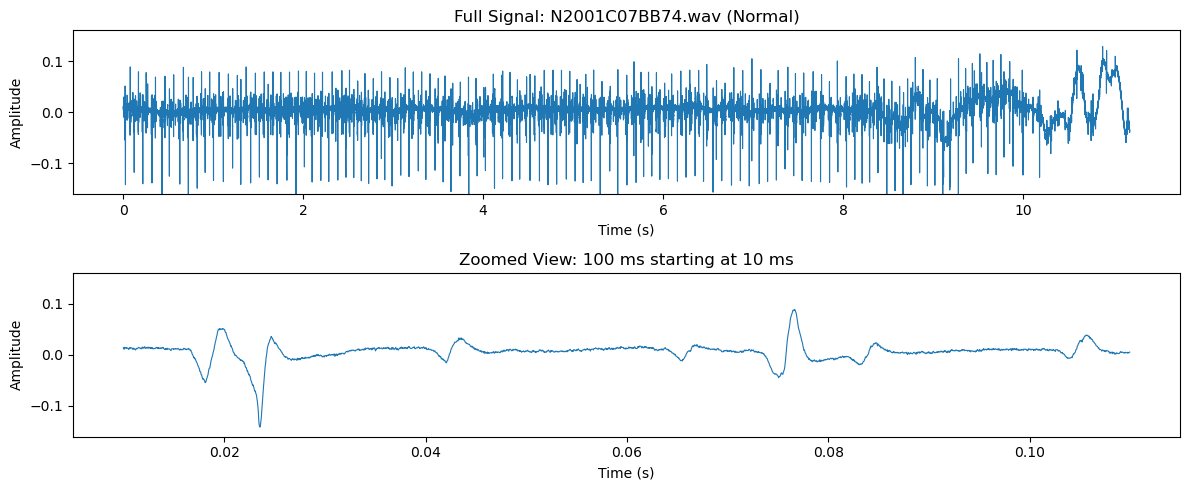

           filename     label  duration_s       rms      mean  peak2peak  \
0  N2001A05BB53.wav       ALS   11.184572  0.021177  0.005888   0.637878   
1  N2001M06BB08.wav  Myopathy   11.184572  0.006651  0.001209   0.116577   
2  N2001C07BB74.wav    Normal   11.184572  0.023807  0.003476   0.320801   

   zero_crossings  muap_peaks  
0            8608         316  
1           16382           0  
2            8071         117  


In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.signal as signal
import scipy.io.wavfile as wav

# -------------------------
# USER SETTINGS
# -------------------------
selected_muscle = "BB"         # 👈 change muscle group (e.g., 'BB', 'VM', 'AP', ...)
samples_per_class = 1          # how many files per label to visualize

data_dir = r"C:\Users\Wibisono\Downloads\Master_Thesis\EMGlabDatabaseWav\EMGlabDatabaseWav"

# Plot controls
ymin, ymax = -0.16, 0.16        # 👈 fixed y-axis range for BOTH plots
zoom_len_ms = 100              # 100 ms window length
zoom_start_ms = 10              # 👈 change this to move the 100 ms window start (ms)

# -------------------------
# FILTER + SAMPLE
# -------------------------
muscle_df = df[df["muscle"] == selected_muscle].copy()

sample_df = (
    muscle_df.groupby("label", group_keys=False)
    .apply(lambda x: x.sample(samples_per_class, random_state=42))
    .reset_index(drop=True)
)

features = []

# -------------------------
# PROCESS FILES
# -------------------------
for _, row in sample_df.iterrows():
    filename = row["filename"]
    if not str(filename).lower().endswith(".wav"):
        filename = str(filename) + ".wav"

    filepath = os.path.join(data_dir, filename)

    try:
        sr, data = wav.read(filepath)

        # if stereo -> take first channel
        if data.ndim > 1:
            data = data[:, 0]

        # normalize int16 to [-1, 1]
        if data.dtype == np.int16:
            data = data.astype(np.float32) / 32768.0
        else:
            data = data.astype(np.float32)

        duration = len(data) / sr
        time = np.arange(len(data)) / sr  # seconds

        # ---- features ----
        rms = np.sqrt(np.mean(data**2))
        mean_val = np.mean(data)
        p2p = np.ptp(data)
        zc = ((data[:-1] * data[1:]) < 0).sum()
        peaks, _ = signal.find_peaks(data, height=0.1)
        n_peaks = len(peaks)

        features.append({
            "filename": row["filename"],
            "label": row["label"],
            "duration_s": duration,
            "rms": rms,
            "mean": mean_val,
            "peak2peak": p2p,
            "zero_crossings": zc,
            "muap_peaks": n_peaks
        })

        # -------------------------
        # PLOTTING (2 SUBPLOTS)
        # -------------------------
        fig, axes = plt.subplots(2, 1, figsize=(12, 5), sharex=False)

        # Full signal
        axes[0].plot(time, data, linewidth=0.8)
        axes[0].set_title(f"Full Signal: {filename} ({row['label']})")
        axes[0].set_xlabel("Time (s)")
        axes[0].set_ylabel("Amplitude")
        axes[0].set_ylim(ymin, ymax)

        # Zoomed signal (custom start)
        zoom_start_s = zoom_start_ms / 1000.0
        zoom_len_s = zoom_len_ms / 1000.0

        start_idx = int(zoom_start_s * sr)
        end_idx = start_idx + int(zoom_len_s * sr)

        # clamp indices
        start_idx = max(0, min(start_idx, len(data) - 1))
        end_idx = max(start_idx + 1, min(end_idx, len(data)))

        axes[1].plot(time[start_idx:end_idx], data[start_idx:end_idx], linewidth=0.8)
        axes[1].set_title(f"Zoomed View: {zoom_len_ms} ms starting at {zoom_start_ms} ms")
        axes[1].set_xlabel("Time (s)")
        axes[1].set_ylabel("Amplitude")
        axes[1].set_ylim(ymin, ymax)

        plt.tight_layout()
        plt.show()

    except FileNotFoundError:
        print(f"File not found: {filepath}")
    except Exception as e:
        print(f"Error reading {filepath}: {e}")

# -------------------------
# RESULTS TABLE
# -------------------------
features_df = pd.DataFrame(features)
print(features_df)


C:\Users\Wibisono\AppData\Local\Temp\ipykernel_28576\3680797590.py:15: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sample_df = label_df.groupby('muscle').apply(lambda x: x.sample(1, random_state=42)).reset_index(drop=True)


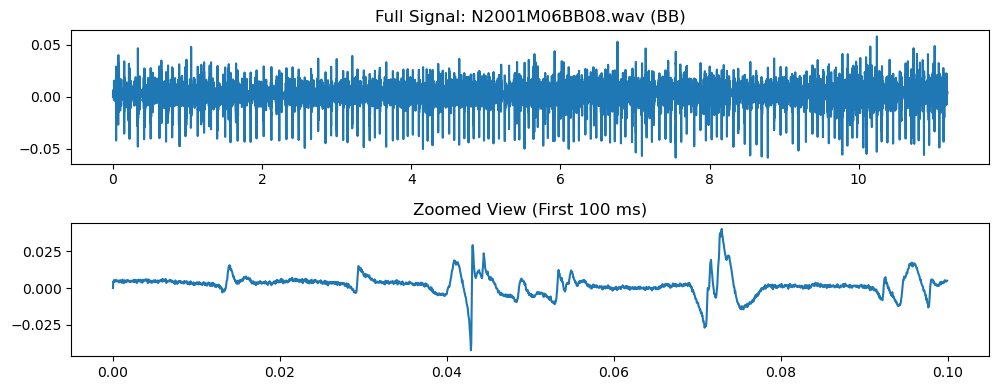

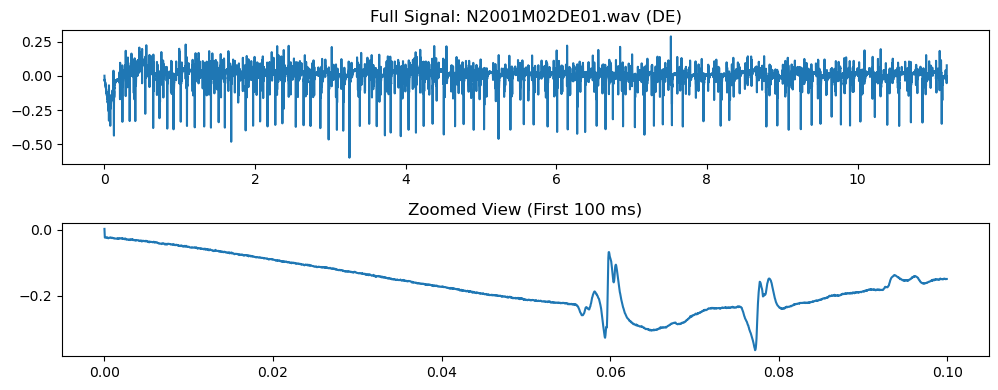

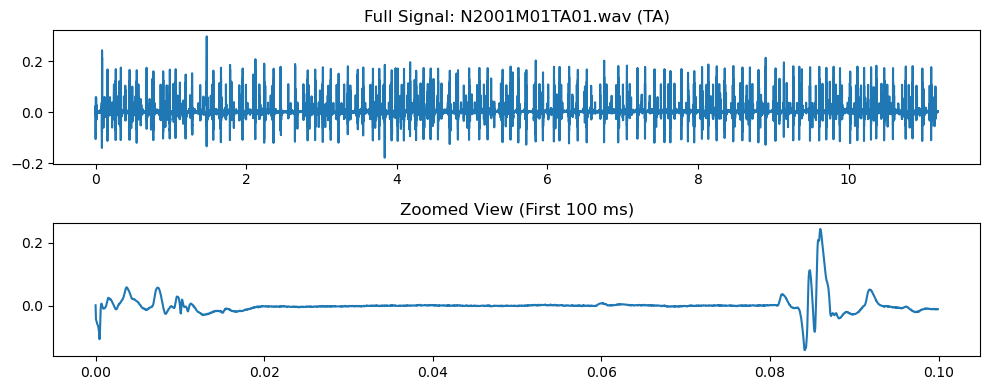

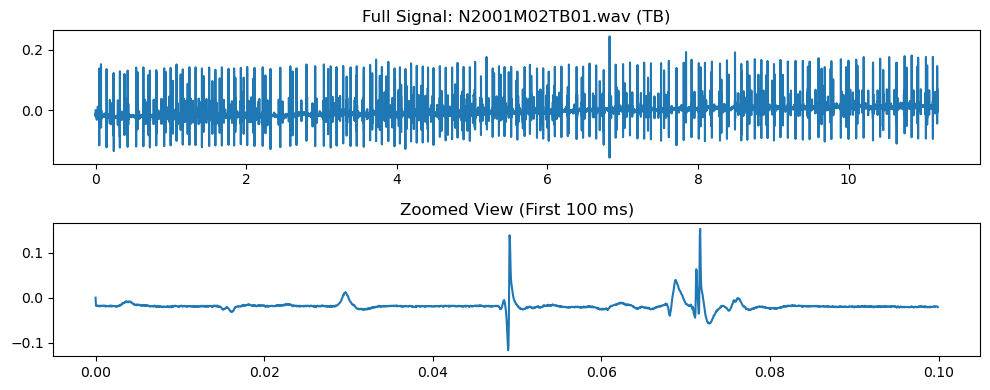

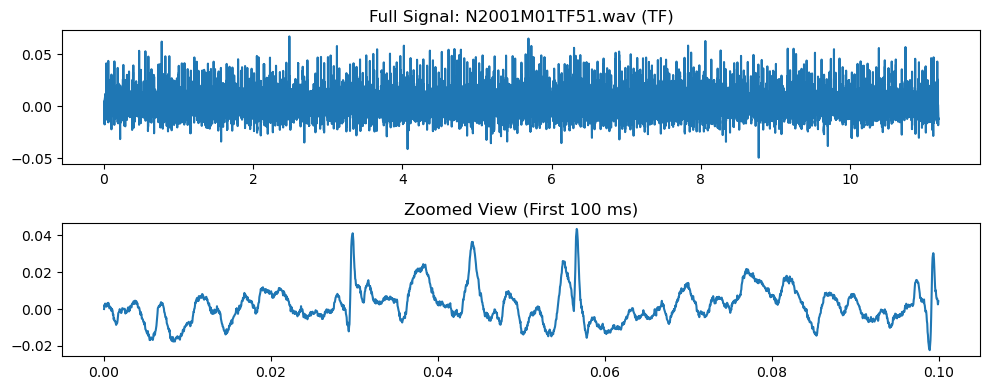

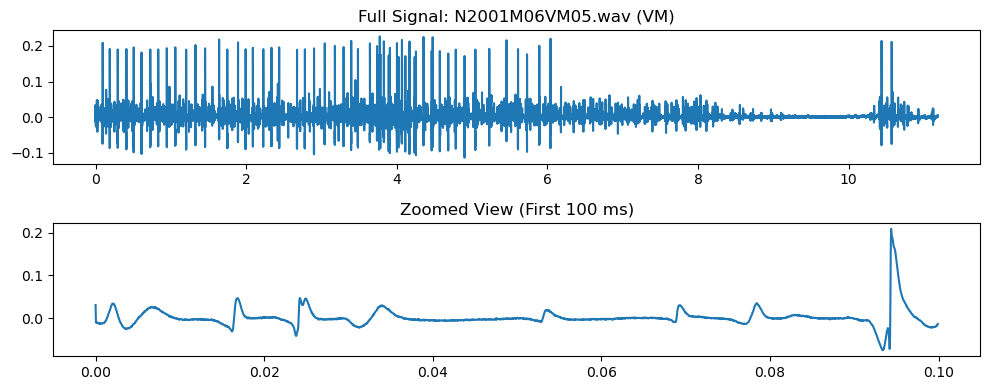

           filename muscle  duration_s       rms      mean  peak2peak  \
0  N2001M06BB08.wav     BB   11.184572  0.006651  0.001209   0.116577   
1  N2001M02DE01.wav     DE   11.184572  0.049929  0.003068   0.888611   
2  N2001M01TA01.wav     TA   11.184572  0.020603  0.002867   0.476807   
3  N2001M02TB01.wav     TB   11.184572  0.016089 -0.004192   0.400909   
4  N2001M01TF51.wav     TF   11.184572  0.010045  0.002141   0.116699   
5  N2001M06VM05.wav     VM   11.184572  0.016020  0.001147   0.339996   

   zero_crossings  muap_peaks  
0           16382           0  
1            3618         534  
2           13441         318  
3            4832         184  
4           10179           0  
5           18787          82  


In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.signal as signal
import scipy.io.wavfile as wav

# Choose the class label to explore
selected_label = "Myopathy"  # Options: 'ALS', 'Myopathy', 'Normal'

# Filter metadata for that class only
label_df = df[df['label'] == selected_label].copy()

# Get one random sample per muscle in that label
sample_df = label_df.groupby('muscle').apply(lambda x: x.sample(1, random_state=42)).reset_index(drop=True)

# Set path to .wav files
data_dir = r"C:\Users\Wibisono\Downloads\Master_Thesis\EMGlabDatabaseWav\EMGlabDatabaseWav"

features = []

for _, row in sample_df.iterrows():
    filename = row["filename"]
    if not filename.lower().endswith(".wav"):
        filename += ".wav"
    filepath = os.path.join(data_dir, filename)

    try:
        sr, data = wav.read(filepath)
        if data.ndim > 1:
            data = data[:, 0]

        if data.dtype == np.int16:
            data = data / 32768.0

        duration = len(data) / sr
        rms = np.sqrt(np.mean(data**2))
        mean_val = np.mean(data)
        p2p = np.ptp(data)
        zc = ((data[:-1] * data[1:]) < 0).sum()
        peaks, _ = signal.find_peaks(data, height=0.1)
        n_peaks = len(peaks)

        features.append({
            "filename": row["filename"],
            "muscle": row["muscle"],
            "duration_s": duration,
            "rms": rms,
            "mean": mean_val,
            "peak2peak": p2p,
            "zero_crossings": zc,
            "muap_peaks": n_peaks
        })

        # --- Plot full and zoomed view ---
        fig, axes = plt.subplots(2, 1, figsize=(10, 4), sharex=False)
        time = np.linspace(0, duration, len(data))

        axes[0].plot(time, data)
        axes[0].set_title(f"Full Signal: {row['filename']} ({row['muscle']})")

        zoom_samples = int(sr * 0.1)
        axes[1].plot(time[:zoom_samples], data[:zoom_samples])
        axes[1].set_title("Zoomed View (First 100 ms)")

        plt.tight_layout()
        plt.show()

    except FileNotFoundError:
        print(f"File not found: {filepath}")
    except Exception as e:
        print(f"Error reading {filepath}: {e}")

# Display extracted features
features_df = pd.DataFrame(features)
print(features_df)


## Downsampling EMG Signals Using tsdownsample

937
Loaded signal from N2001C07BB74.wav
Signal shape: (937,)
Time range: 0.00 - 40.00 ms
Decimate: 37 points kept, 900 points removed
MinMax: 36 points kept, 901 points removed
M4: 36 points kept, 904 points removed
LTTB: 37 points kept, 900 points removed
MinMaxLTTB: 37 points kept, 900 points removed


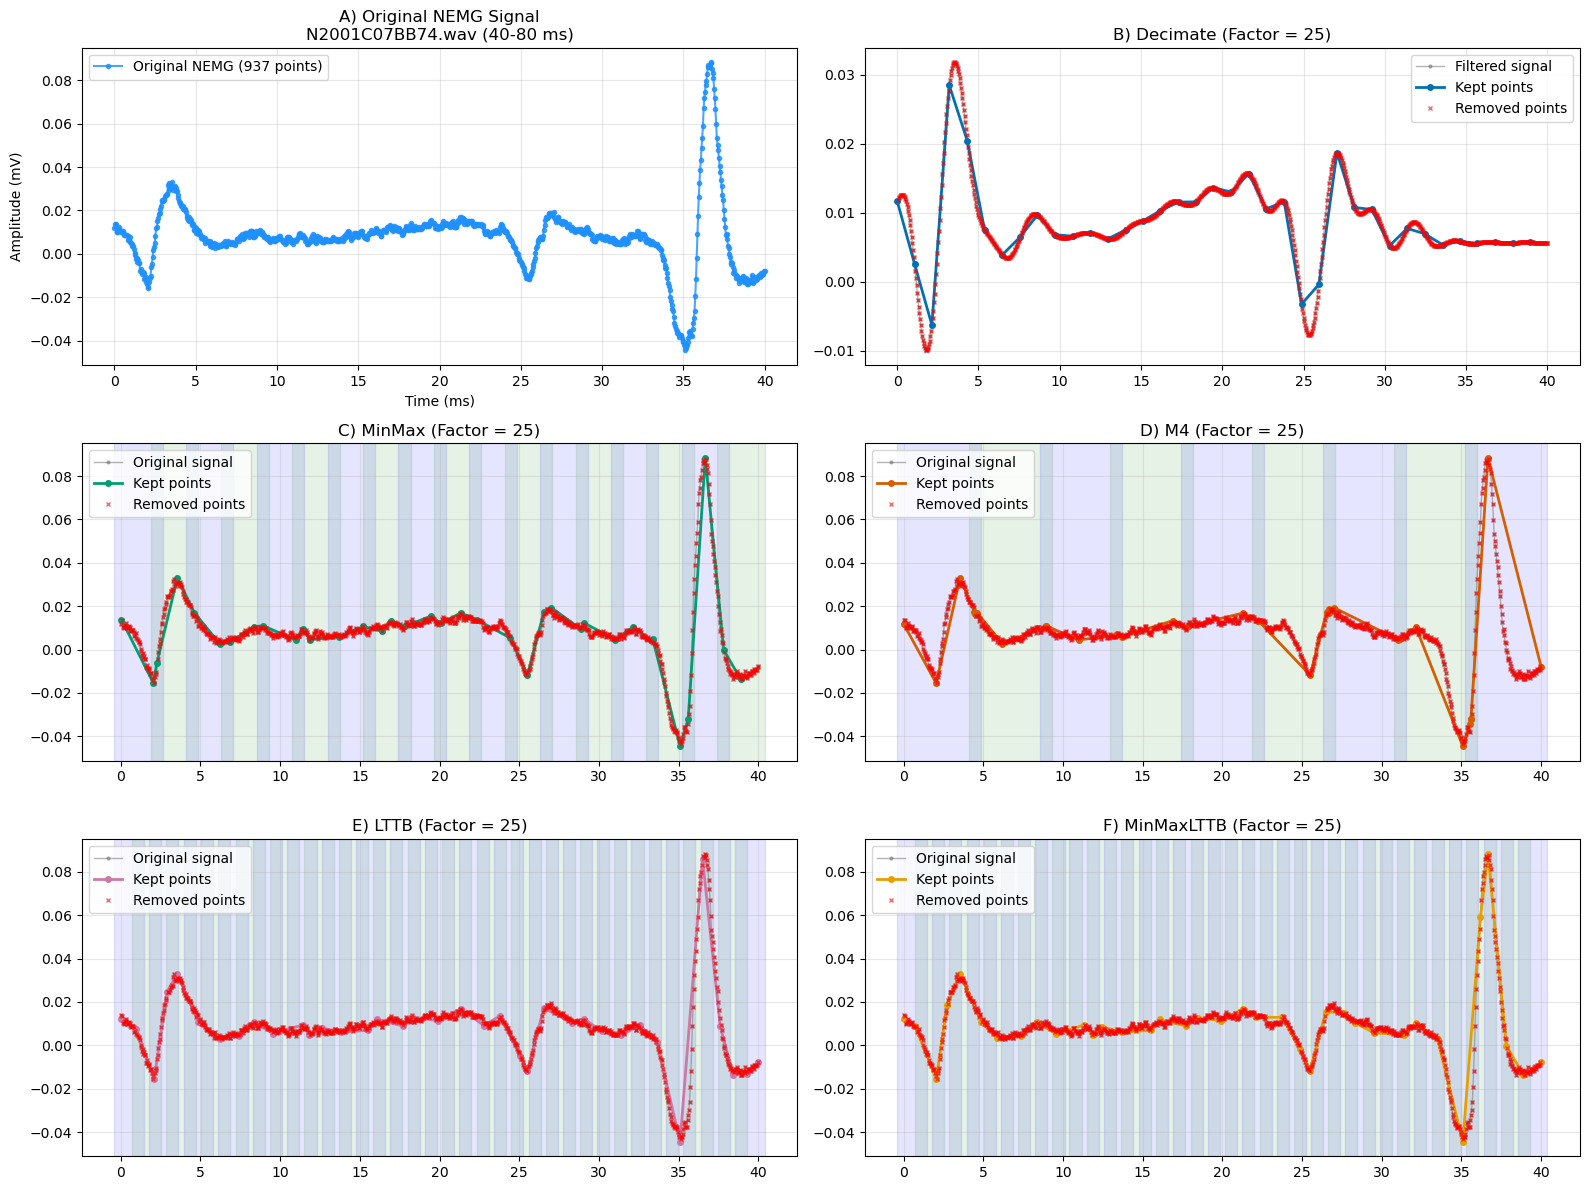

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import scipy.io.wavfile as wav
from tsdownsample import LTTBDownsampler, MinMaxDownsampler, M4Downsampler, MinMaxLTTBDownsampler, EveryNthDownsampler
import itertools
from scipy.signal import firwin, filtfilt

DOWNSAMPLING_COLORS = {
    'Decimate': '#0072B2',  # Blue
    'M4': '#D55E00',  # Vermilion
    'MinMax': '#009E73',  # Bluish green
    'LTTB': '#CC79A7',  # Reddish purple
    'MinMaxLTTB': '#E69F00'  # Orange
}

def add_bins(ax, t, method, factor):
    n_points = len(t)

    if method == "MinMax":
        nb_bins = (n_points // factor) // 2
    elif method == "M4":
        nb_bins = (n_points // factor) // 4
    elif method in ["LTTB", "EveryNth", "MinMaxLTTB"]:
        nb_bins = n_points // factor
    else:
        return

    bins = np.searchsorted(t, np.linspace(t[0], t[-1], nb_bins + 1), side="right")
    bins[0] = 0
    bins[-1] = len(t)

    colors = itertools.cycle(["blue", "green"])

    for i in range(len(bins) - 1):
        t_start = t[bins[i]] - (t[-1] - t[0]) * 0.01
        t_end = t[bins[i + 1] - 1] + (t[-1] - t[0]) * 0.01
        ax.axvspan(t_start, t_end, color=next(colors), alpha=0.1)

def downsample(signal, downsampler, factor):
    mapping = {
        "LTTB": LTTBDownsampler,
        "Decimate": EveryNthDownsampler,
        "MinMax": MinMaxDownsampler,
        "M4": M4Downsampler,
        "MinMaxLTTB": MinMaxLTTBDownsampler
    }
    downsampler_c = mapping[downsampler]
    n_out = len(signal) // factor
    if n_out % 2 != 0 and downsampler_c is MinMaxDownsampler:
        n_out -= 1
    if n_out % 4 != 0 and downsampler_c is M4Downsampler:
        n_out -= n_out % 4
    selected_indices = downsampler_c().downsample(signal, n_out=int(n_out))
    return selected_indices

def filter_signal(signal: np.ndarray, q: int, n: int = None) -> np.ndarray:
    if q <= 1:
        return signal
    if n is None:
        half_len = 10 * q
        n = 2 * half_len
    b = firwin(n + 1, 1. / q, window='hamming')
    a = 1.0
    manual_padlen = min(3 * q, len(signal) - 1)
    filtered_signal = filtfilt(b, a, signal, padlen=manual_padlen)
    return np.ascontiguousarray(filtered_signal)

def load_nemg_segment(filename, data_dir, start_time_ms=0, duration_ms=20, target_points=469):
    """
    Load a segment of NEMG signal from a .wav file
    
    Parameters:
    -----------
    filename : str
        Name of the .wav file
    data_dir : str
        Directory containing the .wav files
    start_time_ms : float
        Start time in milliseconds
    duration_ms : float
        Duration of segment in milliseconds
    target_points : int
        Number of points to extract (will resample if needed)
    
    Returns:
    --------
    signal : np.ndarray
        The extracted signal segment
    time : np.ndarray
        Time array in milliseconds
    """
    if not filename.lower().endswith(".wav"):
        filename += ".wav"
    filepath = os.path.join(data_dir, filename)
    
    sr, data = wav.read(filepath)
    if data.ndim > 1:
        data = data[:, 0]
    
    if data.dtype == np.int16:
        data = data / 32768.0
    
    # Calculate sample indices
    start_sample = int(start_time_ms * sr / 1000)
    end_sample = int((start_time_ms + duration_ms) * sr / 1000)
    
    # Extract segment
    segment = data[start_sample:end_sample]
    
    # Resample to target number of points if needed
    if len(segment) != target_points:
        x_old = np.linspace(0, duration_ms, len(segment))
        x_new = np.linspace(0, duration_ms, target_points)
        segment = np.interp(x_new, x_old, segment)
    
    time = np.linspace(0, duration_ms, target_points)
    
    return segment, time

# ===== CONFIGURATION =====================================================================================
# Set your data directory
data_dir = r"EMGlabDatabaseWav\EMGlabDatabaseWav"

# Choose a file from your dataset
# You can select from sample_df or manually specify
selected_filename = "N2001C07BB74.wav"  # Change this to your desired file

# Time window parameters
start_time_ms = 40  # Start at 100ms
duration_ms = 40   # 20ms window (similar to synthetic MUAP)
target_points = int(23437.5 * (duration_ms/1000)) 
print(target_points)

# Downsampling parameters
downsampling_factor = 25
# ===== LOAD ACTUAL NEMG SIGNAL ============================================================================
try:
    muap, t = load_nemg_segment(
        selected_filename, 
        data_dir, 
        start_time_ms=start_time_ms,
        duration_ms=duration_ms,
        target_points=target_points
    )
    
    print(f"Loaded signal from {selected_filename}")
    print(f"Signal shape: {muap.shape}")
    print(f"Time range: {t[0]:.2f} - {t[-1]:.2f} ms")
    
except Exception as e:
    print(f"Error loading signal: {e}")
    print("Falling back to synthetic MUAP...")
    # Fallback to synthetic if file not found
    # from your_synthetic_code import generate_muap
    # _, muap, t = generate_muap(n_points=469, window=20)

# ===== DOWNSAMPLING COMPARISON =====
methods = ["Decimate", "MinMax", "M4", "LTTB", "MinMaxLTTB"]

fig, axes = plt.subplots(3, 2, figsize=(16, 12))
axes = axes.flatten()

# Plot original signal
axes[0].plot(t, muap, linestyle='-', color='dodgerblue', marker='o', 
             markersize=3, linewidth=1.5, label=f"Original NEMG ({len(muap)} points)", alpha=0.8)
axes[0].set_title(f"A) Original NEMG Signal\n{selected_filename} ({start_time_ms}-{start_time_ms+duration_ms} ms)", 
                  fontsize=12)
axes[0].set_ylabel("Amplitude (mV)")
axes[0].set_xlabel("Time (ms)")
axes[0].grid(True, alpha=0.3)
axes[0].legend()

# Plot each downsampling method
for i, method in enumerate(methods):
    ax = axes[i + 1]
    
    if method == 'Decimate':
        signal = filter_signal(muap, downsampling_factor)
        label = 'Filtered signal'
    else:
        signal = muap
        label = 'Original signal'
        add_bins(ax, t, method, downsampling_factor)
    
    selected_indices = downsample(signal, method, downsampling_factor)
    removed_indices = np.setdiff1d(np.arange(len(signal)), selected_indices)
    
    ax.plot(t, signal, linestyle='-', color='grey', marker='o', 
            markersize=2, linewidth=1, alpha=0.6, label=label)
    ax.plot(t[selected_indices], signal[selected_indices], linestyle='-', 
            color=DOWNSAMPLING_COLORS[method], marker='o', markersize=4, 
            linewidth=2, label=f"Kept points")
    ax.plot(t[removed_indices], signal[removed_indices], linestyle='none', 
            color='red', marker='x', markersize=3, alpha=0.6, label="Removed points")
    
    ax.set_title(f"{chr(66+i)}) {method} (Factor = {downsampling_factor})", fontsize=12)
    ax.grid(True, alpha=0.3)
    ax.legend()
    
    print(f"{method}: {len(selected_indices)} points kept, {len(removed_indices)} points removed")

plt.tight_layout()
plt.show()